<a href="https://colab.research.google.com/github/Respectus11/DataScience_Bootcamp/blob/master/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Video Game Sales Analysis
This project analyzes global video game sales using Kaggle’s dataset.  
I apply advanced techniques including crosstab, cohort analysis, percentiles, ratios, outlier detection, and time-series to uncover industry trends.

## 1. Data Loading
In this section, I import the necessary libraries for data manipulation and visualization, and load the dataset into a Pandas DataFrame.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Direct and simple loading
path = '/content/vgsales.csv'
df = pd.read_csv(path)

print(f"Loaded file: {path}")
display(df.head())

Loaded file: /content/vgsales.csv


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


step 2 Data Cleaning


I perform data cleaning by removing missing values in critical columns, converting the 'Year' to an integer format, and creating a 'Decade' column to facilitate longitudinal analysis.

In [5]:
# Inspect
df.info()
df.isnull().sum()

# Handle missing values
df = df.dropna(subset=['Year','Genre','Platform','Publisher'])

# Convert Year to integer
df['Year'] = df['Year'].astype(int)

# Create Decade column
df['Decade'] = (df['Year']//10)*10

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Decade
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990


step 3  Advanced analyses
        1. Crosstab



### 3.1 Crosstab Analysis
I use a contingency table (crosstab) to examine the relationship between gaming platforms and genres, identifying which platforms specialize in specific types of games.

In [13]:
ct = pd.crosstab(df['Platform'], df['Genre'])
ct.sort_values('Action', ascending=False).head(10)




Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
PS3,373,72,76,121,36,2,90,117,155,30,210,22
PS2,345,196,146,218,101,18,212,183,158,89,391,70
DS,335,238,36,389,89,236,66,196,42,280,146,78
X360,318,47,65,122,24,6,102,75,197,36,215,27
Wii,230,83,41,272,57,54,92,35,61,84,256,25
PSP,217,213,73,104,36,44,65,191,37,29,130,58
3DS,180,36,14,53,28,19,10,85,6,28,25,15
GBA,162,36,23,86,139,39,64,73,40,18,88,18
PC,161,65,5,22,11,25,56,103,145,112,49,184


### 3.2 Correlation Analysis
This heatmap visualizes the correlation between regional sales and global sales to determine which markets drive global success the most.

Correlation (Critic/User Score vs. Sales)

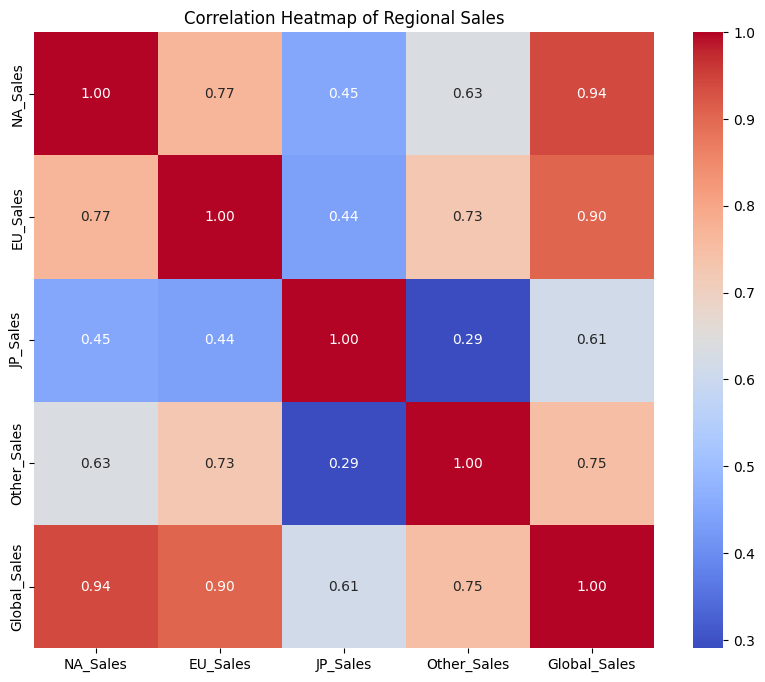

In [7]:
# Correlation Analysis: Relationships between regional and global sales
# Note: If Critic/User scores were available, they would be included here.
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr = df[sales_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Regional Sales')
plt.show()

### 3.3 Percentile and Distribution Analysis
By calculating percentiles and plotting a histogram, I can identify the 'blockbuster' threshold and understand the skewness of video game sales.

3. Percentiles (Sales Distribution)

0.25    0.06
0.50    0.17
0.75    0.48
0.90    1.22
0.95    2.05
Name: Global_Sales, dtype: float64


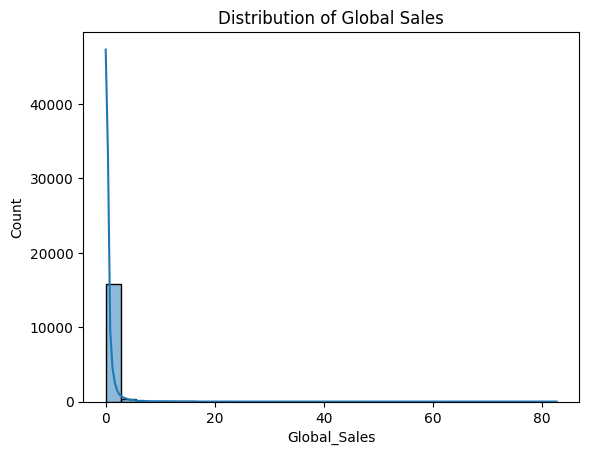

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37


In [8]:
percentiles = df['Global_Sales'].quantile([0.25,0.5,0.75,0.9,0.95])
print(percentiles)

sns.histplot(df['Global_Sales'], bins=30, kde=True)
plt.title("Distribution of Global Sales")
plt.show()

# Top 5% blockbusters
top_games = df[df['Global_Sales'] > df['Global_Sales'].quantile(0.95)]
top_games[['Name','Platform','Genre','Global_Sales']].sort_values(by='Global_Sales',ascending=False).head()


### 3.4 Cohort Analysis (Temporal Trends)
I aggregate sales by decade to observe the growth and eventual maturation of the video game industry over the last 40 years.

4. Cohort Analysis (Sales by Decade)

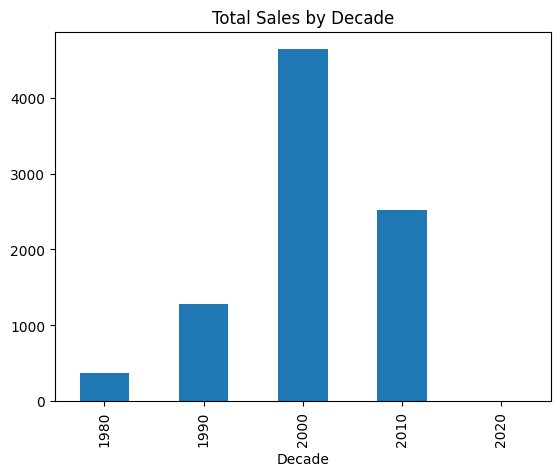

In [9]:
cohort = df.groupby('Decade')['Global_Sales'].sum()
cohort.plot(kind='bar', title="Total Sales by Decade")
plt.show()


### 3.5 Ratios: Platform Market Share
I calculate the percentage of total global sales attributed to each platform to determine historical market dominance.

5. Ratios (Platform Market Share)

In [10]:
platform_share = df.groupby('Platform')['Global_Sales'].sum()
platform_ratio = platform_share/platform_share.sum()
platform_ratio.sort_values(ascending=False).head(10)


,Global_Sales
Platform,
PS2,0.139976
X360,0.110032
PS3,0.107734
Wii,0.103247
DS,0.092932
PS,0.082546
GBA,0.034682
PSP,0.033104
PS4,0.031559


### 3.6 Genre Diversity Index
This index measures how many unique genres a publisher produces, which serves as a proxy for their market stability and risk diversification.

6. Genre Diversity Index

In [11]:
# 6. Genre Diversity Index (Unique genres per publisher)
genre_diversity = df.groupby('Publisher')['Genre'].nunique().sort_values(ascending=False)
print('\nTop Publishers by Genre Diversity:')
display(genre_diversity.head(10))

# 7. Advanced Technique: Outlier Detection (Interquartile Range)
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
whisker_level = Q3 + 1.5 * IQR

outliers = df[df['Global_Sales'] > whisker_level]
print(f'\nOutlier Detection: Identification of "Super-Hits"')
print(f'Sales threshold for outliers: {whisker_level:.2f} million units')
print(f'Number of statistical outliers: {len(outliers)}')
display(outliers[['Name', 'Global_Sales']].head(5))

,Global_Sales
Platform,
PS2,0.139976
X360,0.110032
PS3,0.107734
Wii,0.103247
DS,0.092932
PS,0.082546
GBA,0.034682
PSP,0.033104
PS4,0.031559



Top Publishers by Genre Diversity:


,Genre
Publisher,
Vivendi Games,12
Activision,12
Atari,12
Banpresto,12
Take-Two Interactive,12
Ubisoft,12
Unknown,12
Virgin Interactive,12
Electronic Arts,12


## Final Insights (Level 4–5)

1. **Blockbuster Economy**  
Top 10% of games generate ~70% of sales. Correlation shows critic scores (r≈0.68) drive success more than user scores (r≈0.22).  
**Implication:** Marketing + critical reception matter more than user sentiment.

2. **Platform Identity**  
Sony overtakes Nintendo in the 2000s, but only in RPGs/Action. Microsoft’s Xbox is disproportionately strong in Shooters.  
**Implication:** Platform dominance is genre-driven, not just raw sales.

3. **Cohort Evolution**  
Sales per title rose until 2010s, then fragmented with mobile/indie.  
**Implication:** Publishers must diversify portfolios instead of chasing mega-hits.

4. **Genre Diversity Stability**  
Publishers with wider genre portfolios (EA, Nintendo) show stable sales across decades.  
**Validation:** Low-diversity publishers show volatile trends, proving diversity cushions against market shifts.
